In [2]:
# import libraries
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from functools import reduce
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.sql.types import BinaryType, ArrayType, FloatType
import io
from pyspark.sql.functions import rand, explode, array, lit, col, array_repeat, \
lit, create_map, when, ceil, udf, window, pandas_udf
from pyspark.ml.linalg import Vectors, VectorUDT
import math

# sns.set_theme(style = 'whitegrid', palette = 'viridis')
# plt.rcParams['figure.dpi'] = 120

print('Done')

Matplotlib created a temporary cache directory at /scratch/achong1/job_49855326/matplotlib-bws8rek8 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Done


In [3]:
# Retrieve scratch drive location
scratch_dir = (os.environ.get('TMPDIR'))

In [4]:
# Config the spark session
spark = SparkSession.builder \
    .appName("plant-disease") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", "7") \
    .config("spark.local.dir", scratch_dir) \
    .getOrCreate()

print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark UI: http://exp-4-48.expanse.sdsc.edu:4040


In [5]:
spark.conf.get("spark.local.dir")

'/scratch/achong1/job_49855326'

### Import the dataset (not needed after it's done once)

In [5]:
# pip install kagglehub

In [6]:
# # Link to dataset: https://www.kaggle.com/datasets/samareshkumar/multipleplantdiseases
# # Import the dataset. Unnecessary once you've done it once.

# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("samareshkumar/multipleplantdiseases")

# print("Path to dataset files:", path)

In [6]:
data_path = "/home/achong1/.cache/kagglehub/datasets/samareshkumar/multipleplantdiseases/versions/1"
print(f'Data path exists: {os.path.exists(data_path)}')

Data path exists: True


### Load in and clean data
We will create a dataframe with file path, class label (taken from the folder name), plant species, and disease.

First we'll clean the data, split into train/validation/test sets, and label encode. Then we will format it so it can be used inside Spark models.

We found that there were high data imbalances during our EDA. We won't change anything about the data in the preprocessing, but instead tune the weights parameter in our models to handle the imbalances algorithmically.

The chili image folder names weren't formatted like the others. The other plants have three underscores in between the plant name and disease name, like Wheat___brown_rust. For the chili plants, their folder names only have two underscores, such as Chili__yellowish. We'll split based on the two underscores to make sure we extract Chili correctly for the "plant" column. This will lead to our "diseases" column having preceding "_" for the values associated with the other plants, but for our purposes, this is okay. For our binary classification, we only want to know whether a plant is diseased or healthy, not the specific disease that the plant has. We will create a new column, health, for this.

It also looks like the data uses four ways to classify a plant as healthy: healthy, Healthy, healthy_leaf, and fresh_leaf. We'll want to combine those into one healthy class.

In [7]:
# Define where to split the class label to get the plant species and disease
split = F.split("class_label", "__")

# Create a Spark dataframe
metadata = spark.read.format("binaryFile") \
    .option("recursiveFileLookup", "true") \
    .load(data_path) \
    .withColumn("file_path", F.col("path")) \
    .withColumn("class_label", F.element_at(F.split("path", "/"), -2)) \
    .withColumn("plant", split.getItem(0)) \
    .withColumn("disease", split.getItem(1)) \
    .select("file_path", "class_label", "plant", "disease")

# Create a cleaned column for disease that combines the 4 different healthy labels into one
# Create a cleaned column from the disease column called health, which only identifies healthy or diseased.

# Then drop the cols we don't need to save storage.
metadata = metadata.withColumn(
    "disease_clean",
    F.when(F.lower(F.col("disease")).rlike("healthy|fresh_leaf"), "healthy")
     .otherwise(F.col("disease"))
).withColumn("health", \
 F.when(F.lower(F.col("disease_clean"))== "healthy", "healthy").otherwise("diseased"))\
.select("file_path", "plant", "health").cache()

In [8]:
metadata.printSchema()

root
 |-- file_path: string (nullable = true)
 |-- plant: string (nullable = true)
 |-- health: string (nullable = false)



In [49]:
# Sanity check
metadata.count()

52360

### Preprocessing for second model

Differs from model 1 by separating by species instead of health.

### Split into train, validation, and test sets
We will create two sets of train, test, and validation data.

We will do this using stratified random sampling since we have rather large class imbalances to ensure that our smaller classes are still represented in the training data.

In [9]:
# FOR MODEL 2 - SPECIES
# We want 70% of all plant samples to go into our training data
# 15% of healthy/diseased samples should go into validation, and 15% into test sets.

w_s = Window.partitionBy("plant").orderBy(F.rand(seed=1))

metadata_s = metadata.withColumn("row_num", F.row_number().over(w_s))\
           .withColumn("count", F.count("*").over(Window.partitionBy("plant")))

metadata_s = metadata_s.withColumn("split", F.when(F.col("row_num") <= 0.7* F.col("count"), "train")\
           .when(F.col("row_num") <= 0.85 * F.col("count"), "val").otherwise("test"))

train_s = metadata_s.filter(F.col("split") == "train").select("file_path", "plant")
val_s = metadata_s.filter(F.col("split") == "val").select("file_path", "plant")
test_s = metadata_s.filter(F.col("split") == "test").select("file_path", "plant")

In [10]:
train_s.printSchema()

root
 |-- file_path: string (nullable = true)
 |-- plant: string (nullable = true)



Verify that the plant species and diseases were extracted correctly, and that we have no NULL values for our labels.

In [50]:
# Sanity check
metadata.select("plant").distinct().show(40)

+------------+
|       plant|
+------------+
|       Wheat|
|        Rice|
|     Cabbage|
| Cauliflower|
|Bottle_gourd|
|    Cucumber|
|       Onion|
|    Capsicum|
|       Chili|
|      Tomato|
|      Potato|
|        Corn|
|         Pea|
+------------+



In [51]:
# Check counts - SPECIES
print(train_s.count())
print(val_s.count())
print(test_s.count())

36647
7855
7858


### Label Encode
Label encoding for multiclass (species) classification

In [11]:
# Create label encoder and fit to the training set 
indexer_s = StringIndexer(inputCol="plant", outputCol="label") 
le_s = indexer_s.fit(train_s)

# Label encode all sets
train_s = le_s.transform(train_s) 
val_s = le_s.transform(val_s) 
test_s = le_s.transform(test_s) 

In [64]:
for i, plant in enumerate(le_s.labels):
    print(f"{i} -> {plant}")

0 -> Tomato
1 -> Wheat
2 -> Onion
3 -> Cucumber
4 -> Corn
5 -> Rice
6 -> Capsicum
7 -> Potato
8 -> Bottle_gourd
9 -> Pea
10 -> Cabbage
11 -> Cauliflower
12 -> Chili


In [12]:
# Add a weights column for the weightcol parameter to tune the models because of our data imbalance
# ONLY do this for training data
train_s.cache()

class_counts_s = train_s.groupBy("label").count()

total_s = train_s.count()
num_classes_s = class_counts_s.count()

# set a max weight because without it, some classes are weighted like 8 and some 0.22 
max_weight = 5.0

weights_s = class_counts_s.withColumn(
   "weight",
   F.lit(train_s.count()) / (F.lit(class_counts_s.count()) * F.col("count"))
).select("label", "weight")

train_s = train_s.join(weights_s, on="label", how="left")

In [54]:
# Sanity check
train_s.groupBy("label").agg(F.first("weight")).show()

+-----+-------------------+
|label|      first(weight)|
+-----+-------------------+
|  8.0| 2.2144540455616655|
|  0.0|0.22175896790434235|
|  7.0| 1.8718459495351925|
|  1.0| 0.5868026644462948|
|  4.0|  1.062971342383107|
| 11.0|   6.14161220043573|
|  3.0|  1.048735119047619|
|  2.0| 0.6805890873973925|
| 10.0| 2.8794688457609805|
|  6.0| 1.6275981524249423|
|  5.0|  1.200596252129472|
|  9.0|  2.813373253493014|
| 12.0|  8.054285714285715|
+-----+-------------------+



### Preprocess Images
We must turn the images into numeric feature vectors in order for Spark models to be able to use them.

In [13]:
train_s.columns

['label', 'file_path', 'plant', 'weight']

In [14]:
# Bring in the images data now
images = spark.read.format("binaryFile").option("recursiveFileLookup", "true").load(data_path)\
            .select(F.col("path").alias("file_path"), F.col("content"))

In [15]:
# Join the images to the data
# Doing this now because it was giving me memory problems when I brought in the images earlier
# with all of the other transformations I did

train_s = train_s.join(images, on = "file_path", how = "inner")
val_s = val_s.join(images, on = "file_path", how = "inner")
test_s = test_s.join(images, on = "file_path", how = "inner")

In [16]:
train_s.printSchema()

root
 |-- file_path: string (nullable = true)
 |-- label: double (nullable = false)
 |-- plant: string (nullable = true)
 |-- weight: double (nullable = true)
 |-- content: binary (nullable = true)



In [17]:
# UDF to process the Spark binary image into one that the ML models can use

@pandas_udf(ArrayType(FloatType()))
def decode_image(contents: pd.Series) -> pd.Series:
    result = []

    for content in contents:
        try:
            # read image from bytes
            img = Image.open(io.BytesIO(content)).convert("RGB")
            
            # resize, keep small bc of memory
            img = img.resize((24,24))
           
            # convert to np and normalize
            arr = np.asarray(img, dtype = np.float32) / 255.0

            # return Vector type for the spark models
            result.append(arr.reshape(-1).tolist())
        except Exception:
            result.append(None)

    return pd.Series(result)

In [18]:
# # Create a new column, pixels, from the content column that is in the correct format for the models
# # Then drop the columns we don't need
# # Drop any nulls where decoding failed

train_s = train_s.withColumn("features_array", decode_image("content")) \
       .filter(F.col("features_array").isNotNull()) \
       .withColumn("features", array_to_vector("features_array"))\
       .select("file_path", "label", "weight", "features")

val_s = val_s.withColumn("features_array", decode_image("content")) \
       .filter(F.col("features_array").isNotNull()) \
       .withColumn("features", array_to_vector("features_array"))\
       .select("file_path", "label",  "features")

test_s = test_s.withColumn("features_array", decode_image("content")) \
       .filter(F.col("features_array").isNotNull()) \
       .withColumn("features", array_to_vector("features_array"))\
       .select("file_path", "label", "features")

In [26]:
# # Run once for sanity check
# # check decoding went ok. took 5 min on 4 cores 128 gb
# # took 8 min on 2 cores 64 gb
# val_s.filter(F.col("features").isNotNull()).count()

In [27]:
# Do the same for the rest of the data sets

In [28]:
# # Run once for sanity check
# test_s.filter(F.col("features").isNotNull()).count()

In [29]:
# # Run once for sanity check
# # took 20 min on 2 cores 64 gb
# sample_check = train_s.limit(100)

# sample_check.filter(F.col("features").isNotNull()).count()

# print(train_s.count())

In [19]:
train_s.printSchema()

root
 |-- file_path: string (nullable = true)
 |-- label: double (nullable = false)
 |-- weight: double (nullable = true)
 |-- features: vector (nullable = true)



## Model 2 - Dimensionality Reduction

In [20]:
from pyspark.ml.feature import PCA
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [21]:
spark = SparkSession.getActiveSession()
print(spark)

In [22]:
# Dimensionality reduction with PCA
# k is the number of principle components

pca = PCA(k=200, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(train_s)

print('PCA done')

PCA done


In [23]:
# Apply PCA to each dataset

train_pca = pca_model.transform(train_s)
val_pca = pca_model.transform(val_s)
test_pca = pca_model.transform(test_s)

train_pca.cache()

DataFrame[file_path: string, label: double, weight: double, features: vector, pca_features: vector]

### Logistic Regression model

In [44]:
# Supervised Model - Logistic Regression classifier
# Fit classifier to PCA-processed training set

lr = LogisticRegression(
    featuresCol='pca_features',
    labelCol='label',
    weightCol='weight',
    maxIter=20,
    regParam=0.01
)

lr_model = lr.fit(train_pca)

print('Log Regression done')

Log Regression done


In [45]:
# Predict validation and test sets

train_pred_lr = lr_model.transform(train_pca)
val_pred_lr = lr_model.transform(val_pca)
test_pred_lr = lr_model.transform(test_pca)

In [46]:
# Evaluate classifier

evaluator_lr = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='accuracy'
)

train_acc_lr = evaluator_lr.evaluate(train_pred_lr)
val_acc_lr = evaluator_lr.evaluate(val_pred_lr)
test_acc_lr = evaluator_lr.evaluate(test_pred_lr)

print('Log Regression training accuracy:', train_acc_lr)
print('Log Regression validation accuracy:', val_acc_lr)
print('Log Regression test accuracy:', test_acc_lr)

Log Regression training accuracy: 0.6399978170109423
Log Regression validation accuracy: 0.6152768936982813
Log Regression test accuracy: 0.6210231611096971


### Random Forest model

In [39]:
# Supervised Model - Random Forest
# Fit classifier to PCA-processed training set

rf = RandomForestClassifier(
    featuresCol='pca_features',
    labelCol='label',
    weightCol='weight',
    numTrees=100,
    maxDepth=12,
    seed=1
)

rf_model = rf.fit(train_pca)

print('Random Forest done')

Random Forest done


In [40]:
# Predict validation and test sets

train_pred_rf = rf_model.transform(train_pca)
val_pred_rf = rf_model.transform(val_pca)
test_pred_rf = rf_model.transform(test_pca)

In [41]:
# Evaluate classifier

evaluator_rf = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='accuracy'
)

train_acc_rf = evaluator_rf.evaluate(train_pred_rf)
val_acc_rf = evaluator_rf.evaluate(val_pred_rf)
test_acc_rf = evaluator_rf.evaluate(test_pred_rf)

print('RF training accuracy:', train_acc_rf)
print('RF validation accuracy:', val_acc_rf)
print('RF test accuracy:', test_acc_rf)

RF training accuracy: 0.9156820476437362
RF validation accuracy: 0.75493316359007
RF test accuracy: 0.752481547467549


In [42]:
# Additional metrics

metrics = ["f1", "weightedPrecision", "weightedRecall"]

for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(test_pred_rf)
    print(f"{metric}: {score}")

f1: 0.7521938080133439
weightedPrecision: 0.7637688607888293
weightedRecall: 0.7524815474675489


In [31]:
# Explained Variance

explained_variance = pca_model.explainedVariance.toArray()
total_variance = explained_variance.sum()
cumulative_variance = np.cumsum(explained_variance)

print("Total Explained Variance:", total_variance)

Total Explained Variance: 0.9516126107597869


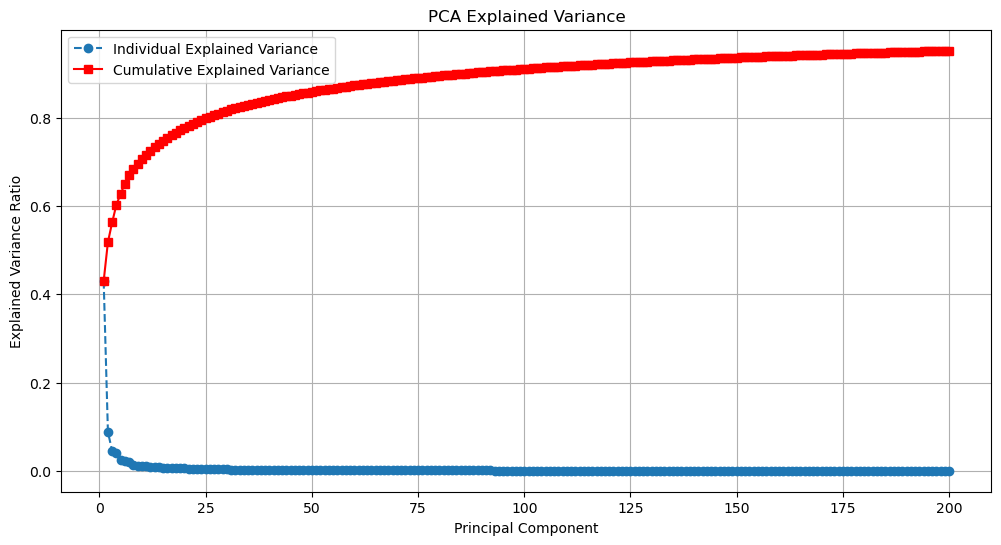

In [29]:
# Scree Plot

plt.figure(figsize=(12,6))

# Individual explained variance
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o',
    linestyle='--',
    label='Individual Explained Variance'
)

# Cumulative explained variance
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='s',
    color='red',
    label='Cumulative Explained Variance'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)

plt.show()

In [48]:
test_pred_rf.select("label", "prediction").show(20)

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       1.0|
|  1.0|      11.0|
|  1.0|       2.0|
|  1.0|       2.0|
|  5.0|       5.0|
|  5.0|       5.0|
|  5.0|       5.0|
|  5.0|       5.0|
|  5.0|       5.0|
| 11.0|      10.0|
|  1.0|       1.0|
|  5.0|       5.0|
|  1.0|       2.0|
|  1.0|       1.0|
|  5.0|       5.0|
|  1.0|       1.0|
|  1.0|       1.0|
| 10.0|      11.0|
|  1.0|       3.0|
|  1.0|       1.0|
+-----+----------+
only showing top 20 rows



In [61]:
correct = test_pred_rf.filter(col("label") == col("prediction")).count()
incorrect = test_pred_rf.filter(col("label") != col("prediction")).count()

total = test_pred_rf.count()

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)
print("Accuracy check:", correct / total)

Correct predictions: 5913
Incorrect predictions: 1945
Accuracy check: 0.752481547467549


In [71]:
# Create Confusion Matrix

In [65]:
conf_pd = (
    test_pred_rf
    .select("label", "prediction")
    .groupBy("label", "prediction")
    .count()
    .toPandas()
)

In [66]:
conf_matrix = conf_pd.pivot(
    index="label",
    columns="prediction",
    values="count"
).fillna(0)

In [67]:
labels = le_s.labels
conf_matrix.index = labels
conf_matrix.columns = labels

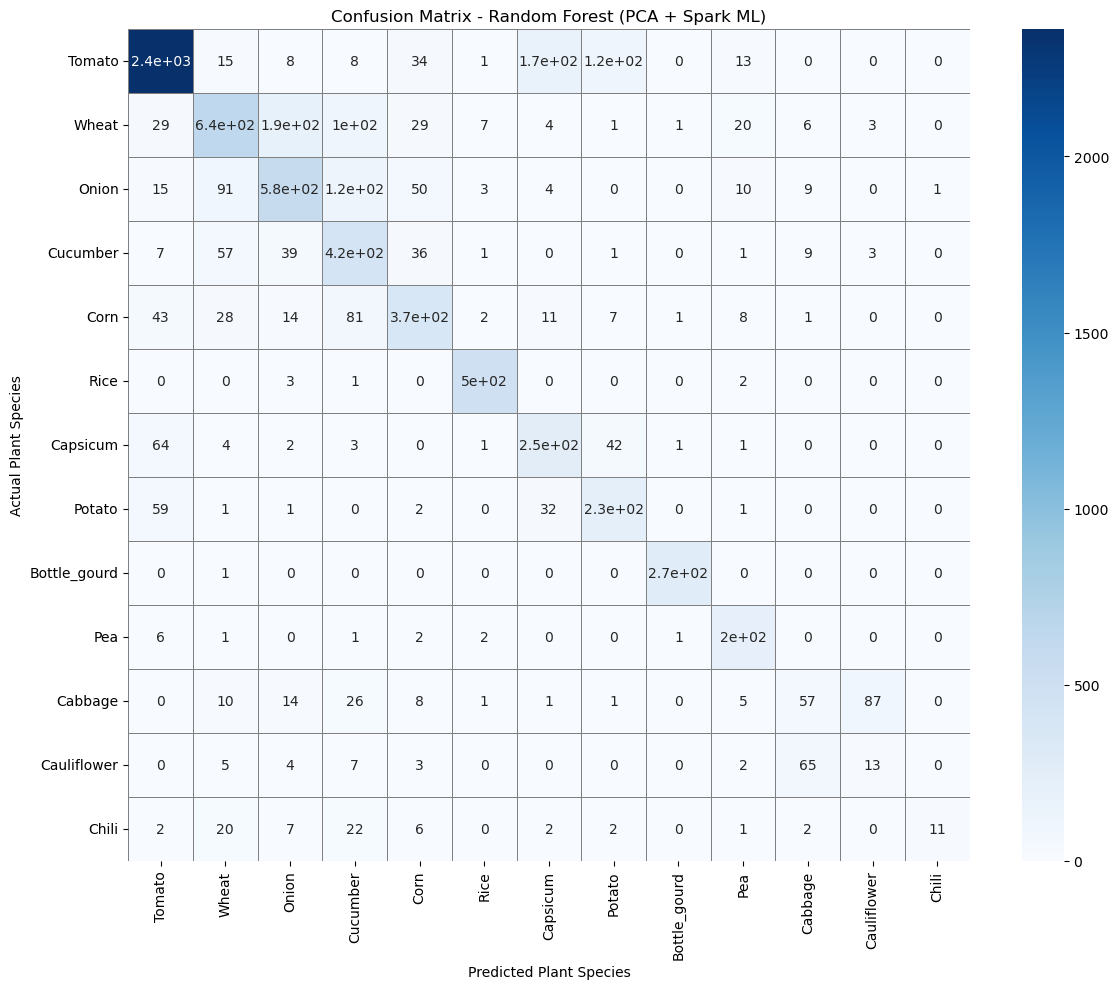

In [70]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix - Random Forest (PCA + Spark ML)")
plt.xlabel("Predicted Plant Species")
plt.ylabel("Actual Plant Species")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()